In [3]:
hst1d<-function(f,tau,b=sd(f)*0.01,prob=c(1/3,1/3,1/3)) # prob=c(l,c,r)
{
  lprob<-prob[1]
  cprob<-prob[2]
  rprob<-prob[3]
  len<-length(f)
  hstresult<-rep(0,len*tau); dim(hstresult)<-c(len,tau)
  hlen<-round(len/2)
  oldf<-f
  f<-c(f[hlen:1],f,f[len:(len-hlen+1)])
  
  ls<-landshape(f)
  f_before<-f
  f_after<-f*0
  L<-length(f)

  for(i in 1:tau)
  {
    minindex<-which(ls=="minimum")
    maxindex<-which(ls=="maximum")
    incindex<-which(ls=="increasing")
    decindex<-which(ls=="decreasing")
    flatindex<-which(ls=="flat")
    epsilon<-runif(1)*b
    f_after[minindex]<-f_before[minindex]+epsilon+epsilon*lprob+epsilon*rprob
    f_after[maxindex]<-f_before[maxindex]+epsilon*cprob
    f_after[incindex]<-f_before[incindex]+epsilon*(cprob+rprob)+epsilon*(lprob)
    f_after[decindex]<-f_before[decindex]+epsilon*(cprob+lprob)+epsilon*(rprob)
    f_after[flatindex]<-f_before[flatindex]+epsilon*cprob+epsilon*rprob*0.5+epsilon*lprob*0.5
    ls<-landshape(f_after)
    f_before<-f_after
    hstresult[,i]<-f_after[(hlen+1):(L-hlen)]
  }
  cbind(oldf,hstresult)
}

landshape<-function(f)
{
  len<-length(f)
  ls<-f*0
  ls[c(1,len)]<-"flat"
  for(i in 2:(len-1))
  {
    if((f[i]>f[i-1])&(f[i]<f[i+1])) ls[i]<-"increasing"
    else if((f[i]<f[i-1])&(f[i]>f[i+1])) ls[i]<-"decreasing"
    else if(mean(c(f[i-1],f[i+1]))<f[i]) ls[i]<-"maximum"
    else if(mean(c(f[i-1],f[i+1]))>f[i]) ls[i]<-"minimum"
    else ls[i]<-"flat"
  }
  ls
}

In [1]:
## define the function 
f<-c(rnorm(512,0,0.5),rnorm(512,5,0.5))

In [ ]:
## set the snow parameter
scaleindex<-120
switer<-50
swalpha<-0.01
swshift<-c(1/3,1/3)
impnq=30
impniter=50
impnsample=50

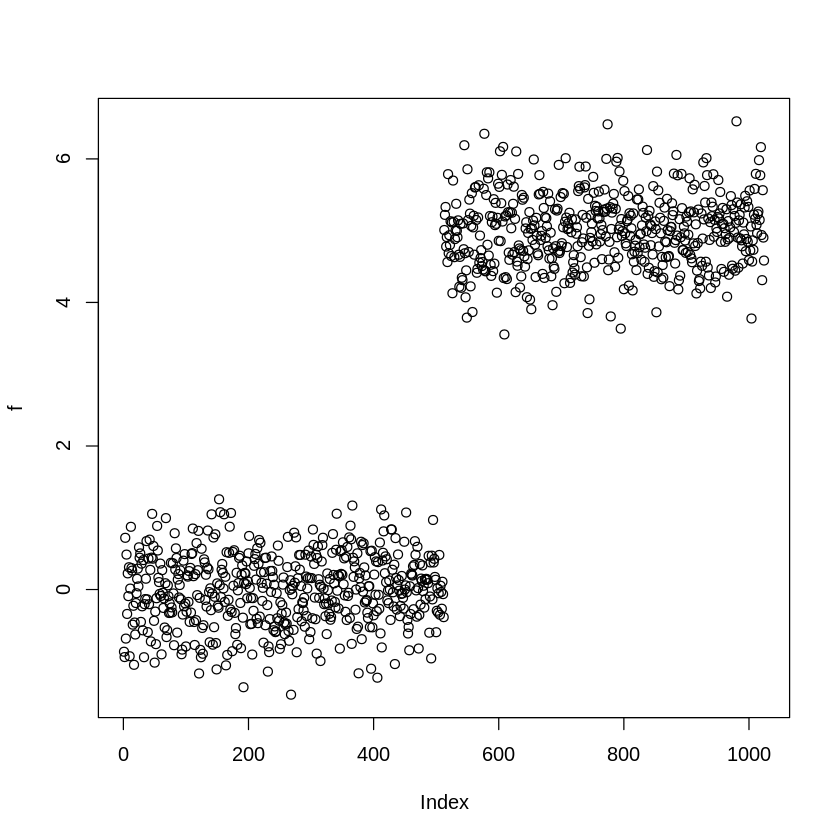

In [2]:
plot(f)

In [8]:
hstrlst<-hst1d(f,tau=120)

In [11]:
hstrlst

oldf,,,,,,,,,,⋯,,,,,,,,,,
-0.86647806,-0.85815468,-0.85445342,-0.847352083,-0.81532230,-0.81204713,-0.78202287,-0.77426011,-0.76186938,-0.75853509,⋯,0.9693207,0.9716046,1.0087464,1.015226,1.052535,1.052677,1.052973,1.077958,1.082712,1.098728
-0.94089671,-0.89927980,-0.88077352,-0.845266837,-0.82604897,-0.80967310,-0.79165854,-0.75284477,-0.74541033,-0.74340976,⋯,0.9634562,0.9748757,0.9971607,1.029556,1.051942,1.052656,1.054134,1.069125,1.092896,1.102506
0.72091807,0.72924145,0.73294270,0.740044041,0.74645000,0.74972517,0.75573002,0.76349278,0.76597092,0.76663778,⋯,1.4839923,1.4908440,1.5131291,1.532566,1.554952,1.555380,1.556267,1.571258,1.585521,1.595130
-0.68342615,-0.64180923,-0.62330295,-0.587796270,-0.55576649,-0.53939062,-0.50936636,-0.47055258,-0.45816185,-0.45482756,⋯,1.4868743,1.4937260,1.5160111,1.535448,1.557834,1.558262,1.559149,1.574140,1.588403,1.598012
0.48707149,0.49539487,0.49909613,0.506197464,0.51260342,0.51587859,0.52188345,0.52964620,0.53212435,0.53279121,⋯,1.4905250,1.4973767,1.5196618,1.539099,1.561485,1.561913,1.562800,1.577791,1.592053,1.601663
-0.33998036,-0.29836345,-0.27985717,-0.244350485,-0.21232071,-0.19594483,-0.16592057,-0.12710680,-0.11471607,-0.11138178,⋯,1.4930407,1.4998924,1.5221775,1.541615,1.564000,1.564429,1.565316,1.580306,1.594569,1.604179
0.22514270,0.23346609,0.23716734,0.244268679,0.25067464,0.25394981,0.25995466,0.26771742,0.27019556,0.27086242,⋯,1.5101250,1.5169767,1.5392618,1.558699,1.581085,1.581513,1.582400,1.597391,1.611653,1.621263
-0.09182906,-0.05021215,-0.03170587,0.003800813,0.03583059,0.05220646,0.08223073,0.12104450,0.13343523,0.13676952,⋯,1.5155246,1.5223763,1.5446614,1.564099,1.586484,1.586912,1.587799,1.602790,1.617053,1.626663
0.31096837,0.31929176,0.32299301,0.330094350,0.33650031,0.33977548,0.34578033,0.35354309,0.35602123,0.35668809,⋯,1.5166241,1.5234758,1.5457609,1.565198,1.587584,1.588012,1.588899,1.603890,1.618153,1.627762
-0.92922675,-0.88760983,-0.86910356,-0.833596874,-0.80156709,-0.78519122,-0.75516696,-0.71635319,-0.70396246,-0.70062817,⋯,1.5182148,1.5250665,1.5473516,1.566789,1.589174,1.589603,1.590490,1.605480,1.619743,1.629353


In [13]:
hstrlsttemp_<-list()
for 

In [ ]:
msw<-function(scaleindex,f,sw.niter=1,sw.alpha=0.02,sw.shift=c(0.5,0.5),imp.nq=10,imp.niter=50,imp.nsample=200)
{
  n<-length(f)
  PC<-list()
  d<-list()
  optq<-list()
  imp<-list()
  r<-list()
  #fhat<-list()
  hstrlst<-hst1d(f,tau)
  ## PCA 
  PCrslt<-princomp(hstrlst)
  ## IMPORTANCE
  distancematrix<-distance(hstrlst)
    
    optq[[s]]<-opt.q(d[[s]],nq=imp.nq,niter=imp.niter,nsample=imp.nsample)
    r[[s]]<-quantile(d[[s]][upper.tri(d[[s]], diag = FALSE)],optq[[s]]$optq)
    fhat[[s]]<-apply(optq[[s]]$fhat[,optq[[s]]$optqindex,],1,mean)
    imp[[s]]<-importance(d[[s]],r[[s]])
    imp[[s]]<-(imp[[s]]/(max(imp[[s]])-min(imp[[s]]))-min(imp[[s]]/(max(imp[[s]])-min(imp[[s]]))))*1000+1
    
  list(f=f,fiter=fiter,PC=PC,d=d,optq=optq,imp=imp,r=r,fhat=fhat)
}